# 3a — Modèles sensibles à l'échelle (CRISP-DM Phase 4)

Cette famille regroupe les modèles dont la fonction objectif ou la métrique de similarité dépend de l'**échelle** des features — donc **tous** doivent recevoir des données normalisées (`preprocessor_scaled`).

| Modèle           | Hypothèse principale                                                                                  |
|------------------|--------------------------------------------------------------------------------------------------------|
| OLS              | Linéarité, résidus normaux et homoscédastiques, pas de multicolinéarité parfaite                       |
| Ridge            | Idem OLS, tolère la multicolinéarité par shrinkage — features comparables en échelle indispensables   |
| Lasso            | Idem Ridge + parcimonie : suppose qu'une minorité de coefficients sont non-nuls                        |
| ElasticNet       | Compromis Ridge/Lasso                                                                                  |
| KNN              | Distance euclidienne pertinente — features comparables en échelle indispensables                       |
| MLPRegressor     | Approximation lisse par réseau de neurones — descente de gradient sensible à l'échelle                |
| SVR              | Marge ε-insensible + noyau RBF basé sur les distances — mise à l'échelle obligatoire                   |

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
X_train : (1166, 79)   |   X_test : (292, 79)
NaN dans X_train : 6276 cellules sur 92114
  num_zero        (10 cols)
  num_median      (26 cols)
  ordinal         (10 cols)
  nominal_none    ( 9 cols)
  nominal_mode    (23 cols)
  total           (78 cols routées, sur 79 dans X_train ; 'Utilities' droppée)
Variantes de préprocesseur :
  preprocessor_scaled  : ColumnTransformer
  preprocessor_encoded : ColumnTransformer
  preprocessor_native  : NativeCategoricalTransformer

Helpers : rmsle_score, cv_rmsle, predicted_vs_actual_plot, publish_result

Données prêtes — X_train (1166, 79), X_test (292, 79)


In [2]:
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

FAMILY = 'scaled'

## 4.1 OLS (régression linéaire ordinaire) — baseline

### Hypothèses du modèle
1. **Linéarité** entre les features et `y_log` — vérifiable par les résidus-vs-fitted.
2. **Indépendance** des erreurs — vérifiable par Durbin-Watson.
3. **Homoscédasticité** (variance constante des résidus) — vérifiable par scale-location + Breusch-Pagan.
4. **Normalité** des résidus — vérifiable par Q-Q plot + Jarque-Bera.
5. **Pas de multicolinéarité parfaite** — partiellement adressée par le retrait prévu des features redondantes (`GarageArea`/`TotalBsmtSF`/`TotRmsAbvGrd`/`GarageYrBlt`).

**Préprocesseur** : `preprocessor_scaled` — OLS n'a pas strictement besoin de la mise à l'échelle (les coefficients absorbent l'unité), mais on l'inclut pour cohérence et meilleure stabilité numérique.

OLS — CV RMSLE: 0.1307   Holdout RMSLE: 0.1306   fit_time: 0.32s


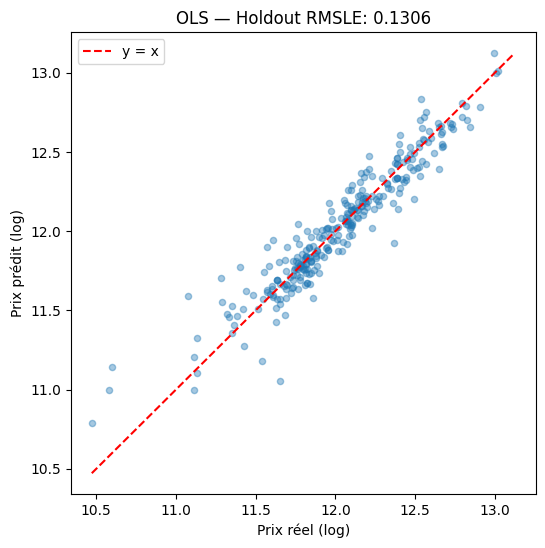

PosixPath('results/family_scaled.json')

In [3]:
t0 = time.time()
ols_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LinearRegression()),
])
ols_pipe.fit(X_train, y_train_log)
ols_fit_s = time.time() - t0

ols_pred_log = ols_pipe.predict(X_test)
ols_holdout = rmsle_score(y_test_log, ols_pred_log)
ols_cv = cv_rmsle(ols_pipe, X_train, y_train_log)

print(f"OLS — CV RMSLE: {ols_cv:.4f}   Holdout RMSLE: {ols_holdout:.4f}   fit_time: {ols_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ols_pred_log, title=f"OLS — Holdout RMSLE: {ols_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'OLS', cv_rmsle=ols_cv, holdout_rmsle=ols_holdout, fit_time_s=ols_fit_s)

### Diagnostic des hypothèses OLS

On ajuste une régression `statsmodels` sur les mêmes features transformées (le préprocesseur est déjà ajusté sur `X_train` — pas de fuite) pour obtenir le **résumé complet** `sm.OLS().summary()` : table des coefficients **et** bloc de diagnostics (Durbin-Watson, Omnibus, Jarque-Bera, Cond. No.). On le complète par le test de **Breusch-Pagan** (homoscédasticité, absent du résumé par défaut) et trois graphiques :

- **Linéarité** → résidus vs valeurs ajustées (nuage centré sur 0, sans structure).
- **Indépendance** → Durbin-Watson (≈ 2 attendu, lu dans le résumé).
- **Homoscédasticité** → scale-location + Breusch-Pagan.
- **Normalité des résidus** → Q-Q plot (`sm.qqplot`) + Jarque-Bera (lu dans le résumé).

In [4]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Le préprocesseur du pipeline OLS est déjà ajusté sur X_train -> on réutilise sa transformation (pas de fuite)
prep_fitted = ols_pipe.named_steps['preprocessor']
X_train_t = prep_fitted.transform(X_train)
X_train_t = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else np.asarray(X_train_t)
feat_names = prep_fitted.get_feature_names_out()

X_sm = sm.add_constant(pd.DataFrame(X_train_t, columns=feat_names, index=X_train.index))
ols_sm = sm.OLS(y_train_log.values, X_sm).fit()

# Résumé complet : coefficients + bloc diagnostics (Durbin-Watson, Omnibus, Jarque-Bera, Cond. No.)
print(ols_sm.summary())

# Homoscédasticité : Breusch-Pagan (absent du résumé statsmodels par défaut)
bp_lm, bp_p, _, _ = het_breuschpagan(ols_sm.resid, X_sm)
print(f"\nBreusch-Pagan (homoscédasticité) : LM={bp_lm:.1f}, p={bp_p:.2e}   (p < 0.05 -> hétéroscédasticité)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     81.17
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        00:17:53   Log-Likelihood:                 1160.6
No. Observations:                1166   AIC:                            -1883.
Df Residuals:                     947   BIC:                            -774.8
Df Model:                         218                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

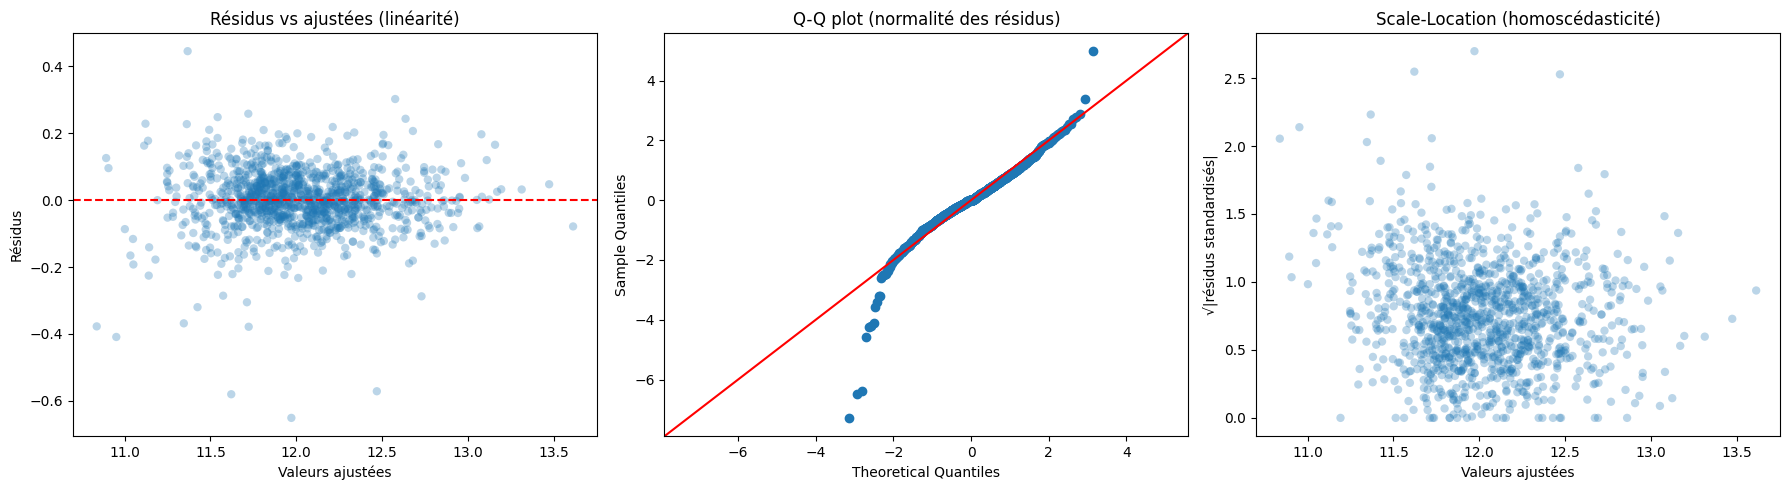

In [5]:
# Graphiques de diagnostic sur les résidus d'entraînement
resid = ols_sm.resid
fitted = ols_sm.fittedvalues
std_resid = resid / resid.std(ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted, resid, alpha=0.3, edgecolor='none')
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Valeurs ajustées', ylabel='Résidus', title='Résidus vs ajustées (linéarité)')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot (normalité des résidus)')
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, edgecolor='none')
axes[2].set(xlabel='Valeurs ajustées', ylabel='√|résidus standardisés|', title='Scale-Location (homoscédasticité)')
plt.tight_layout()
plt.show()

**Lecture des diagnostics :**

- **Indépendance — OK.** Durbin-Watson ≈ 2.00 : aucune autocorrélation des résidus (attendu, les observations ne sont pas une série temporelle).
- **Homoscédasticité — OK.** Breusch-Pagan non significatif (p ≈ 0.51) et le scale-location reste plat : la **transformation log de la cible** a bien stabilisé la variance (sans elle, les maisons chères dominaient l'erreur absolue).
- **Normalité — VIOLÉE.** Jarque-Bera massivement significatif (p ≈ 0), skew ≈ −0.95 et kurtosis ≈ 9.6 : résidus à **queues lourdes** et légèrement asymétriques à gauche. Le Q-Q plot décroche aux extrémités → quelques biens **fortement sous-estimés** (maisons atypiques / de luxe non capturées par une relation linéaire).
- **Colinéarité — sévère.** Le nombre de conditions est gigantesque : le one-hot complet introduit le **piège des variables muettes** (colonnes linéairement dépendantes) en plus des couples redondants vus en EDA. La matrice est quasi-singulaire.

**Conséquence pédagogique :** OLS reste une **baseline** honnête (R² in-sample ≈ 0.95) mais deux hypothèses cassent — normalité et conditionnement. C'est exactement ce qui motive la suite de cette famille : **Ridge / Lasso / ElasticNet** (régularisation contre la colinéarité) puis des modèles non-linéaires robustes aux queues lourdes (familles `3b`/`3c`).

## 4.2 Ridge — pénalité L2

### Hypothèses du modèle
- Mêmes que OLS, mais Ridge **shrinke** les coefficients vers 0 sans en annuler aucun. Tolère la multicolinéarité (un peu) et stabilise l'estimation.
- L'hypothèse cruciale : les **features sont comparables en échelle**, sinon la pénalité L2 (somme des carrés des coefficients) frappe les features de grande amplitude davantage que les autres. → `preprocessor_scaled` est **mandatory**.

On utilise `RidgeCV` pour sélectionner automatiquement le meilleur `alpha` par cross-validation interne.

Ridge — CV RMSLE: 0.1154   Holdout RMSLE: 0.1226   alpha*: 23.36   fit_time: 1.49s


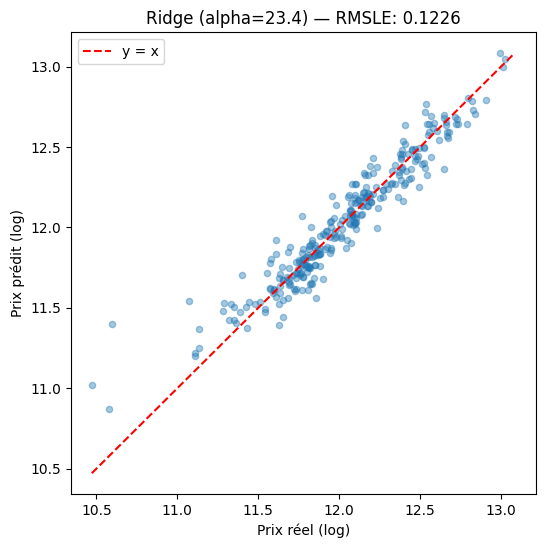

PosixPath('results/family_scaled.json')

In [6]:
t0 = time.time()
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5)),
])
ridge_pipe.fit(X_train, y_train_log)
ridge_fit_s = time.time() - t0
ridge_alpha = ridge_pipe.named_steps['model'].alpha_

ridge_pred_log = ridge_pipe.predict(X_test)
ridge_holdout = rmsle_score(y_test_log, ridge_pred_log)
ridge_cv = cv_rmsle(ridge_pipe, X_train, y_train_log)

print(f"Ridge — CV RMSLE: {ridge_cv:.4f}   Holdout RMSLE: {ridge_holdout:.4f}   alpha*: {ridge_alpha:.4g}   fit_time: {ridge_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ridge_pred_log, title=f"Ridge (alpha={ridge_alpha:.3g}) — RMSLE: {ridge_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Ridge', cv_rmsle=ridge_cv, holdout_rmsle=ridge_holdout, fit_time_s=ridge_fit_s, params={'alpha': ridge_alpha})

## 4.3 Lasso — pénalité L1

### Hypothèses du modèle
- Idem Ridge, mais avec pénalité L1 (somme des **valeurs absolues**) — provoque la **sélection de variables** : certains coefficients sont mis à exactement 0.
- Hypothèse implicite : le « vrai » modèle est **parcimonieux** (la plupart des features ne contribuent pas).
- L'échelle est encore plus critique qu'avec Ridge.

Lasso — CV RMSLE: 0.1154   Holdout RMSLE: 0.1169   alpha*: 0.0004281   fit_time: 0.16s
  variables annulées : 145 / 256 (57%)


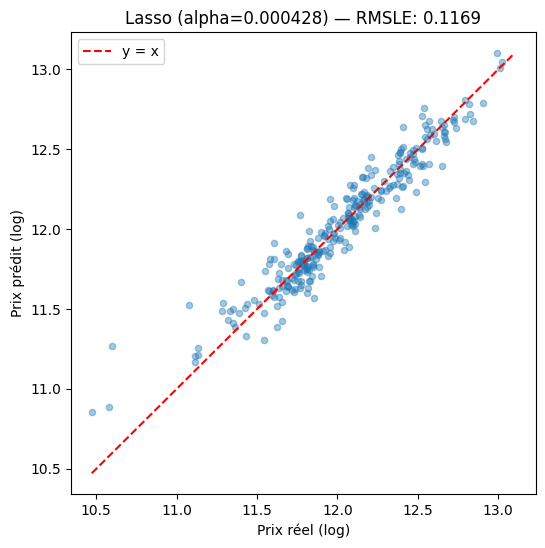

PosixPath('results/family_scaled.json')

In [7]:
t0 = time.time()
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50_000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(X_train, y_train_log)
lasso_fit_s = time.time() - t0
lasso_alpha = lasso_pipe.named_steps['model'].alpha_

lasso_pred_log = lasso_pipe.predict(X_test)
lasso_holdout = rmsle_score(y_test_log, lasso_pred_log)
lasso_cv = cv_rmsle(lasso_pipe, X_train, y_train_log)

coefs = lasso_pipe.named_steps['model'].coef_
n_zero = int((coefs == 0).sum())
print(f"Lasso — CV RMSLE: {lasso_cv:.4f}   Holdout RMSLE: {lasso_holdout:.4f}   alpha*: {lasso_alpha:.4g}   fit_time: {lasso_fit_s:.2f}s")
print(f"  variables annulées : {n_zero} / {len(coefs)} ({100*n_zero/len(coefs):.0f}%)")
predicted_vs_actual_plot(y_test_log, lasso_pred_log, title=f"Lasso (alpha={lasso_alpha:.3g}) — RMSLE: {lasso_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Lasso', cv_rmsle=lasso_cv, holdout_rmsle=lasso_holdout, fit_time_s=lasso_fit_s,
               params={'alpha': lasso_alpha, 'n_zero_coefs': n_zero, 'n_total_coefs': len(coefs)})

## 4.4 ElasticNet — compromis L1 + L2

### Hypothèses du modèle
- Mélange Ridge et Lasso via le paramètre `l1_ratio`. Sélectionne des features (comme Lasso) tout en partageant la pénalité entre plusieurs features corrélées (comme Ridge).
- Pertinent quand on a des **groupes de features corrélées** — exactement notre cas (cf. NB1 : `GarageCars`/`GarageArea`, `TotalBsmtSF`/`1stFlrSF`).

ElasticNet — CV RMSLE: 0.1156   Holdout RMSLE: 0.1169   alpha*: 0.0004281   l1_ratio*: 1.0   fit_time: 1.53s


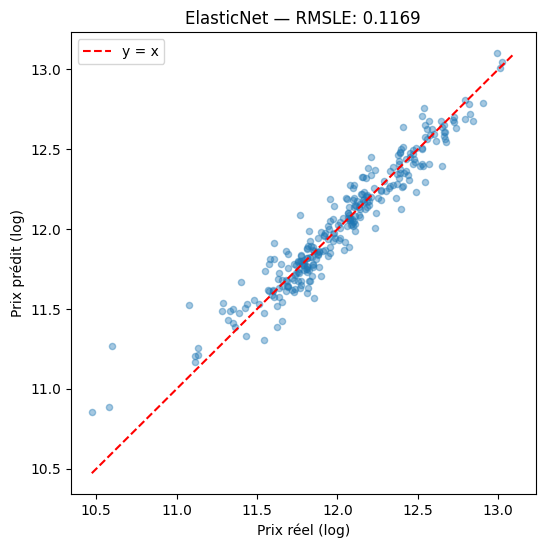

PosixPath('results/family_scaled.json')

In [8]:
t0 = time.time()
enet_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
        alphas=np.logspace(-4, 2, 20),
        cv=5, max_iter=50_000, random_state=RANDOM_STATE,
    )),
])
enet_pipe.fit(X_train, y_train_log)
enet_fit_s = time.time() - t0
enet_alpha = enet_pipe.named_steps['model'].alpha_
enet_l1 = enet_pipe.named_steps['model'].l1_ratio_

enet_pred_log = enet_pipe.predict(X_test)
enet_holdout = rmsle_score(y_test_log, enet_pred_log)
enet_cv = cv_rmsle(enet_pipe, X_train, y_train_log)

print(f"ElasticNet — CV RMSLE: {enet_cv:.4f}   Holdout RMSLE: {enet_holdout:.4f}   alpha*: {enet_alpha:.4g}   l1_ratio*: {enet_l1}   fit_time: {enet_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, enet_pred_log, title=f"ElasticNet — RMSLE: {enet_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'ElasticNet', cv_rmsle=enet_cv, holdout_rmsle=enet_holdout, fit_time_s=enet_fit_s,
               params={'alpha': enet_alpha, 'l1_ratio': enet_l1})

## 4.5 KNN — k plus proches voisins

### Hypothèses du modèle
- **Aucune hypothèse paramétrique** sur la forme de la relation features↔cible — non-paramétrique.
- Hypothèse implicite : deux points proches dans l'espace des features ont des valeurs `y` proches → la **distance euclidienne** doit avoir un sens.
- Conséquence directe : **toutes les features doivent être à la même échelle**, sans quoi les features de grande amplitude dominent la distance. → `preprocessor_scaled` indispensable.

On balaie `k ∈ [1, 40]` et on choisit le `k` qui maximise le R² en CV.

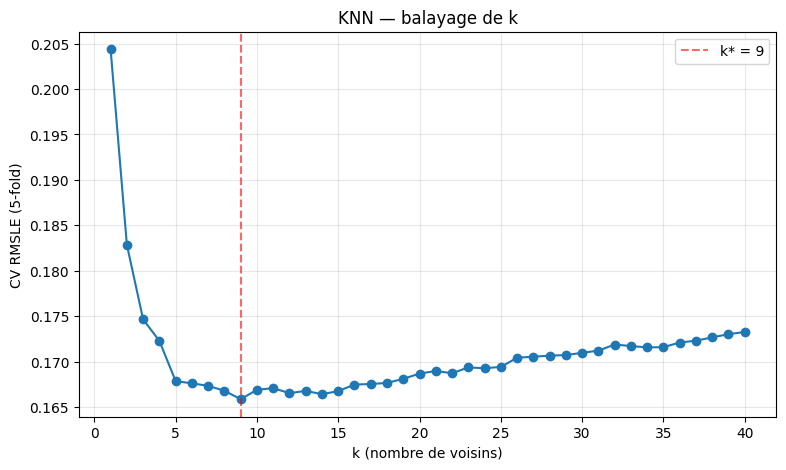

KNN — CV RMSLE: 0.1659   Holdout RMSLE: 0.1759   k*: 9   fit_time (sweep + final): 6.83s


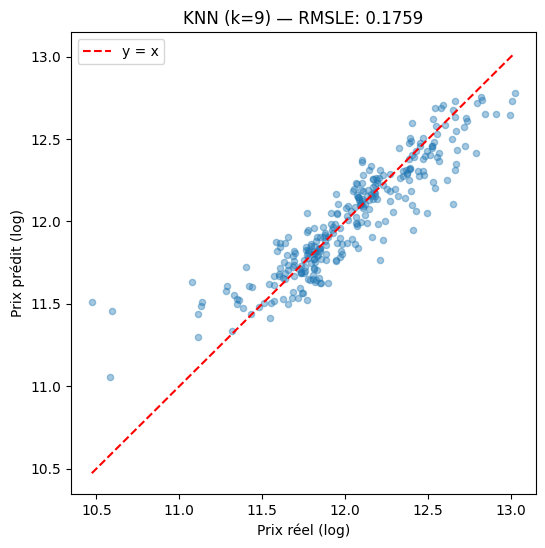

PosixPath('results/family_scaled.json')

In [9]:
t0 = time.time()
k_range = list(range(1, 41))
knn_cv_scores = []
for k in k_range:
    pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=k))])
    knn_cv_scores.append(-cross_val_score(pipe, X_train, y_train_log, cv=5,
                                          scoring='neg_root_mean_squared_error', n_jobs=-1).mean())

best_k = int(k_range[int(np.argmin(knn_cv_scores))])

plt.figure(figsize=(9, 5))
plt.plot(k_range, knn_cv_scores, marker='o')
plt.axvline(best_k, color='red', ls='--', alpha=0.6, label=f'k* = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('CV RMSLE (5-fold)')
plt.title("KNN — balayage de k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

knn_pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=best_k))])
knn_pipe.fit(X_train, y_train_log)
knn_fit_s = time.time() - t0
knn_pred_log = knn_pipe.predict(X_test)
knn_holdout = rmsle_score(y_test_log, knn_pred_log)
knn_cv = float(min(knn_cv_scores))

print(f"KNN — CV RMSLE: {knn_cv:.4f}   Holdout RMSLE: {knn_holdout:.4f}   k*: {best_k}   fit_time (sweep + final): {knn_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, knn_pred_log, title=f"KNN (k={best_k}) — RMSLE: {knn_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'KNN', cv_rmsle=knn_cv, holdout_rmsle=knn_holdout, fit_time_s=knn_fit_s, params={'k': best_k})

## 4.6 MLPRegressor — réseau de neurones tabulaire

### Hypothèses du modèle
- Approximation de fonction lisse par couches denses + activation non-linéaire.
- **Descente de gradient** : très sensible à l'échelle des features (sans normalisation, le gradient explose dans certaines directions et stagne dans d'autres).
- Nécessite une **taille de couche cachée** raisonnable et un **early-stopping** pour éviter le surapprentissage.

On utilise une architecture modeste (1 couche de 64 unités) car notre jeu est petit (≈ 1200 obs train).

MLP — CV RMSLE: 0.2450   Holdout RMSLE: 0.1912   fit_time: 12.10s


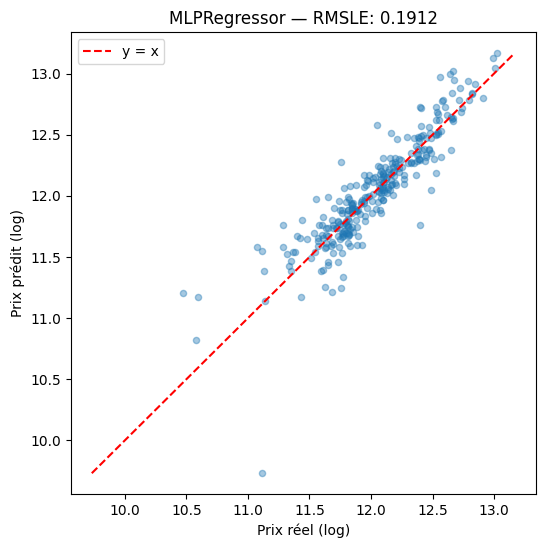

PosixPath('results/family_scaled.json')

In [10]:
t0 = time.time()
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=1500,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    )),
])
mlp_pipe.fit(X_train, y_train_log)
mlp_fit_s = time.time() - t0
mlp_pred_log = mlp_pipe.predict(X_test)
mlp_holdout = rmsle_score(y_test_log, mlp_pred_log)
mlp_cv = cv_rmsle(mlp_pipe, X_train, y_train_log)

print(f"MLP — CV RMSLE: {mlp_cv:.4f}   Holdout RMSLE: {mlp_holdout:.4f}   fit_time: {mlp_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, mlp_pred_log, title=f"MLPRegressor — RMSLE: {mlp_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'MLPRegressor', cv_rmsle=mlp_cv, holdout_rmsle=mlp_holdout, fit_time_s=mlp_fit_s,
               params={'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam'})

## 4.7 SVR — machine à vecteurs de support (régression)

### Hypothèses du modèle
- **Marge ε-insensible** : SVR n'est pénalisé que pour les erreurs dépassant `epsilon`. Les points à l'intérieur du tube ε ne contribuent pas → modèle déterminé par un sous-ensemble de points, les **vecteurs de support** (parcimonie).
- **Noyau RBF** : projette implicitement les features dans un espace de grande dimension → **frontière non-linéaire**. SVR capture donc des interactions que les modèles linéaires de cette famille (OLS/Ridge/Lasso/ElasticNet) ne voient pas — comme MLP, mais sans réseau de neurones.
- **Sensibilité à l'échelle** : le noyau RBF repose sur des **distances** entre points ; une feature de grande amplitude dominerait le noyau. → `preprocessor_scaled` est indispensable (même justification que KNN).
- **Diagnostics vérifiables** : RMSLE en CV et sur le holdout, scatter prédit-vs-réel, résidus vs prédictions, et la **fraction de vecteurs de support** (proxy de complexité — une fraction élevée trahit une frontière très flexible, donc un risque de surapprentissage).
- **Limites** : entraînement et scoring en **O(n²–n³)** — lent à servir en production face au budget de latence du ML Canvas (< 5 s) ; **peu interprétable** (pas de coefficients lisibles comme Lasso) ; performance très sensible au couple `C` / `gamma`, d'où la petite recherche par grille ci-dessous.

**Préprocesseur** : `preprocessor_scaled`.

SVR (RBF) — CV RMSLE: 0.1130   Holdout RMSLE: 0.1177   fit_time (grid+final): 4.87s
  meilleurs hyperparamètres : C=10, gamma=0.001, epsilon=0.05
  vecteurs de support : 598/1166 (51%) — élevé = frontière complexe / risque de surapprentissage


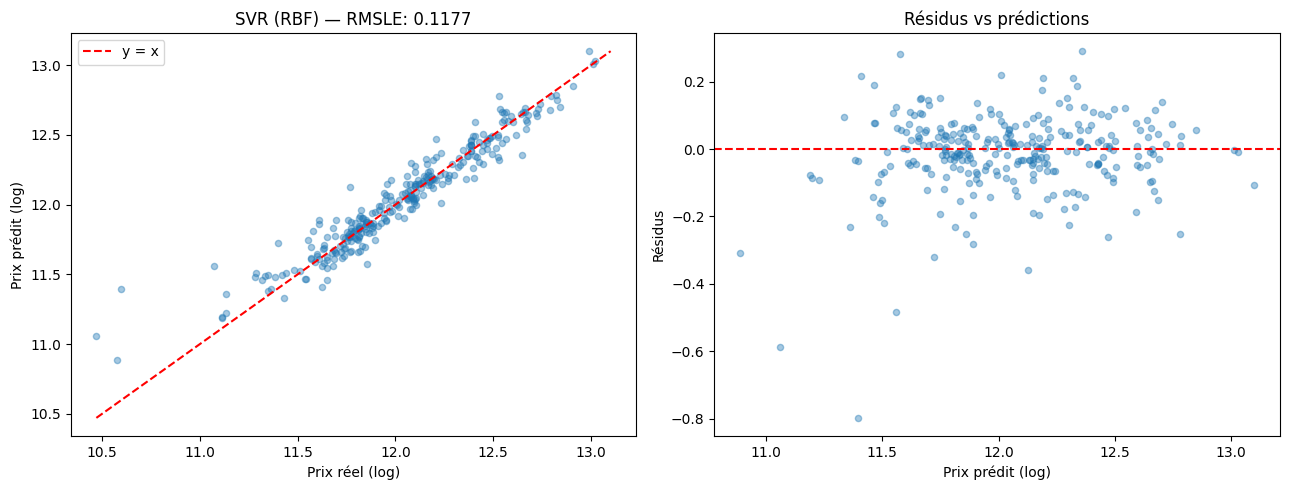

PosixPath('results/family_scaled.json')

In [11]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

t0 = time.time()
svr_base = Pipeline([('preprocessor', preprocessor_scaled), ('model', SVR(kernel='rbf'))])
svr_grid = {
    'model__C':       [1, 10, 100],
    'model__gamma':   ['scale', 0.01, 0.001],
    'model__epsilon': [0.05, 0.1],
}
svr_search = GridSearchCV(svr_base, svr_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
svr_search.fit(X_train, y_train_log)
svr_fit_s = time.time() - t0

svr_pipe     = svr_search.best_estimator_
svr_cv       = float(-svr_search.best_score_)        # RMSLE CV 5-fold du meilleur config
svr_pred_log = svr_pipe.predict(X_test)
svr_holdout  = rmsle_score(y_test_log, svr_pred_log)
best = svr_search.best_params_
n_sv = int(svr_pipe.named_steps['model'].support_.shape[0])
n_tr = X_train.shape[0]

print(f"SVR (RBF) — CV RMSLE: {svr_cv:.4f}   Holdout RMSLE: {svr_holdout:.4f}   fit_time (grid+final): {svr_fit_s:.2f}s")
print(f"  meilleurs hyperparamètres : C={best['model__C']}, gamma={best['model__gamma']}, epsilon={best['model__epsilon']}")
print(f"  vecteurs de support : {n_sv}/{n_tr} ({100*n_sv/n_tr:.0f}%) — élevé = frontière complexe / risque de surapprentissage")

resid = y_test_log.values - svr_pred_log
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
predicted_vs_actual_plot(y_test_log, svr_pred_log, title=f"SVR (RBF) — RMSLE: {svr_holdout:.4f}", ax=axes[0])
axes[1].scatter(svr_pred_log, resid, alpha=0.4, s=20)
axes[1].axhline(0, color='red', ls='--')
axes[1].set(xlabel='Prix prédit (log)', ylabel='Résidus', title='Résidus vs prédictions')
plt.tight_layout()
plt.show()

publish_result(FAMILY, 'SVR', cv_rmsle=svr_cv, holdout_rmsle=svr_holdout, fit_time_s=svr_fit_s,
               params={'kernel': 'rbf', 'C': best['model__C'], 'gamma': best['model__gamma'],
                       'epsilon': best['model__epsilon'], 'n_support': n_sv})

**À retenir.** SVR apporte la non-linéarité au sein de la famille « scaled » (comme le MLP, mais sans réseau). Son intérêt dépend de son RMSLE face au coût : entraînement/scoring quadratique et faible interprétabilité le pénalisent en production. On ne le retiendra comme base learner du stacking (`3d`) que s'il décorrèle utilement ses erreurs de celles des autres familles ; sinon il reste un point de comparaison pédagogique du « kernel trick ».

## 4.8 Comparaison intra-famille

On compare les RMSLE des modèles sensibles à l'échelle. C'est cette comparaison qui désigne le **champion de famille** qui sera proposé comme base learner dans le notebook `3d_stacking.ipynb`.

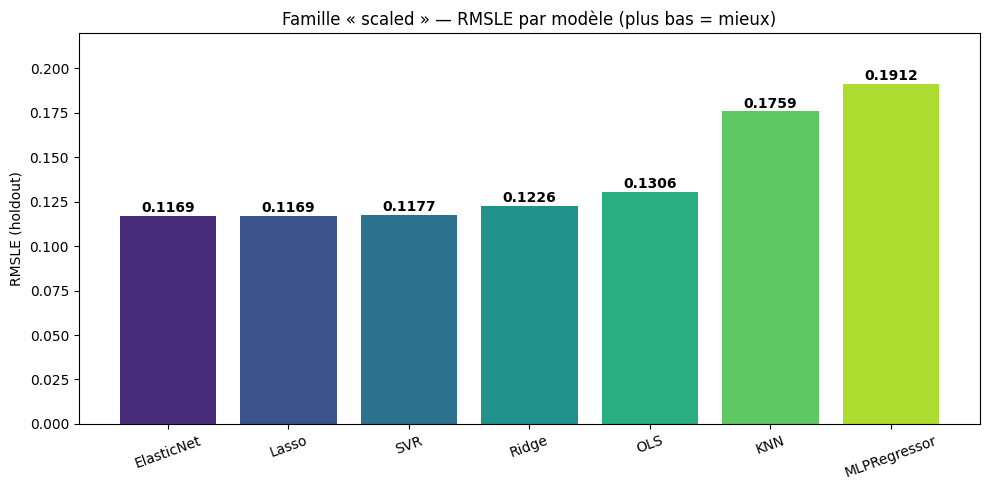

Classement intra-famille (par holdout RMSLE) :


,model,cv_rmsle,holdout_rmsle,fit_time_s
0,ElasticNet,0.115619,0.116925,1.533904
1,Lasso,0.115408,0.116925,0.161206
2,SVR,0.113045,0.117678,4.866556
3,Ridge,0.115436,0.122647,1.489067
4,OLS,0.130672,0.130592,0.317780
5,KNN,0.165857,0.175879,6.829702
6,MLPRegressor,0.244971,0.191216,12.104829


In [12]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))
fam = fam.sort_values('holdout_rmsle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « scaled » — RMSLE par modèle (plus bas = mieux)")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Classement intra-famille (par holdout RMSLE) :")
display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

In [13]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    OLS=ols_pred_log, Ridge=ridge_pred_log, Lasso=lasso_pred_log,
    ElasticNet=enet_pred_log, KNN=knn_pred_log, MLPRegressor=mlp_pred_log, SVR=svr_pred_log,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results/preds_scaled.npz
